In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats
import pandas as pd

import json

SMALL_SIZE = 18
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc('font', size=SMALL_SIZE)          # controls default text sizesa
plt.rc('axes', titlesize=18)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=12)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=15)    # legend fontsize
plt.rc('figure', titlesize=35)  # fontsize of the figure title

plt.rcParams.update({
"text.usetex": True,
"font.family": "serif",
"text.latex.preamble": r"\usepackage{amsmath}"
})

In [2]:
# Hyperparameters
gamma = 0.99
gamma_list = np.cumprod(np.repeat(gamma, 20))

In [5]:
def calc_cost(dir):
    with open(dir, 'r') as f:
        sim = json.load(f)

    cost_list = []
    cost_list_total = []
    sim_rounds = len(sim)
    num_sites = len(sim[0]['hist_cost'])
    
    for i in range(sim_rounds): # Sim
        cost_list_sim = []
        for j in range(num_sites): # Site
            total_cost = 0
            total_time = 0
            for time, cost in sim[i]['hist_cost'][j]:
                # print(cost, cost * (gamma ** total_time), total_time)
                total_cost += cost * (gamma ** total_time)
                total_time += time

            total_cost /= ((1-gamma**(total_time+1))/(1-gamma))
            cost_list.append(-total_cost)
            cost_list_sim.append(-total_cost)
        cost_list_total.append(np.mean(cost_list_sim))
        
    return cost_list, cost_list_total

In [12]:
folder_name = "run_2026-03-22-20-19-15"
collab_file_name = f"experiment_results/{folder_name}/50_2_15_0_nasa1_collaborative_/result.json"
iso_file_name = f"experiment_results/{folder_name}/50_2_15_0_nasa1_isolated_/result.json"
ep_file_name = f"experiment_results/{folder_name}/50_2_15_0_nasa1_EP_/result.json"
collab_lap_1_file_name = f"experiment_results/{folder_name}/50_2_15_1.0_nasa1_collaborative_/result.json"
collab_lap_2_file_name = f"experiment_results/{folder_name}/50_2_15_3.0_nasa1_collaborative_/result.json"

collab_cost, collab_cost_total = calc_cost(collab_file_name)
iso_cost, iso_cost_total = calc_cost(iso_file_name)
ep_cost, ep_cost_total = calc_cost(ep_file_name)
collab_1_cost, collab_1_cost_total = calc_cost(collab_lap_1_file_name)
collab_2_cost, collab_2_cost_total = calc_cost(collab_lap_2_file_name)

In [14]:
sim_accu = [collab_cost, collab_1_cost, collab_2_cost, ep_cost , iso_cost]
sim_accu_total = [collab_cost_total, collab_1_cost_total, collab_2_cost_total, ep_cost_total, iso_cost_total]
df_data = pd.DataFrame(columns=['collab', 'collab_1', 'collab_2', 'EP', 'isolated'])
df_data['collab'] = collab_cost
df_data['collab_1'] = collab_1_cost
df_data['collab_2'] = collab_2_cost
df_data['isolated'] = iso_cost
df_data['EP'] = ep_cost

/tmp/ipykernel_10894/2450980747.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(sim_accu, labels=['Collaborative', 'Federated small', 'Federated large', 'EP', 'Isolated'])


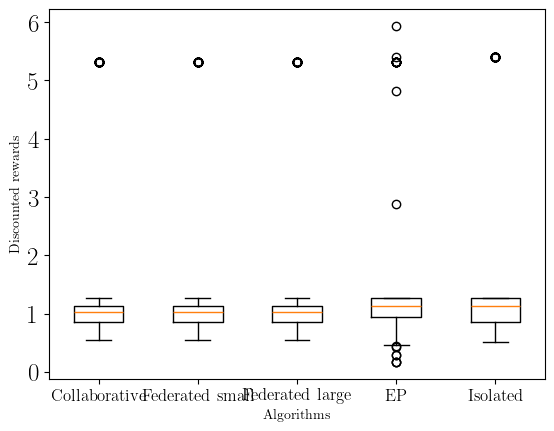

In [18]:
fig, ax = plt.subplots()
ax.boxplot(sim_accu, labels=['Collaborative', 'Federated small', 'Federated large', 'EP', 'Isolated'])
ax.set_xlabel("Algorithms")
ax.set_ylabel("Discounted rewards")

# plt.title("Discounted rewards")
fig.savefig('nasa_boxplot.png')
plt.show()

In [21]:
df_data.describe()

,collab,collab_1,collab_2,EP,isolated
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,1.087644,1.088309,1.091084,1.103830,1.130894
std,0.637964,0.637979,0.638003,0.460936,0.654757
min,0.550141,0.550141,0.550141,0.170590,0.512989
25%,0.854167,0.854167,0.854167,0.936321,0.862494
50%,1.024928,1.024928,1.024928,1.127747,1.127747
75%,1.133245,1.133245,1.133245,1.268661,1.268661
max,5.319179,5.319179,5.319179,5.934608,5.406470


In [24]:
np.mean(collab_cost), np.mean(iso_cost)

(1.1919184609568596, 0.9719807257472146)

In [25]:
np.std(collab_cost), np.std(iso_cost)

(1.4176873363562357, 1.0351476717052108)

In [19]:
N = len(df_data)
std_collab = np.std(collab_cost)
std_iso = np.std(iso_cost)
mu_collab = np.mean(collab_cost)
mu_iso = np.mean(iso_cost)
se = np.sqrt(std_collab**2 / N + std_iso**2 / N)
t_stat = (mu_collab - mu_iso) / se
t_stat

np.float64(-1.832964343291789)

In [20]:
t_crit_val = stats.t.ppf(0.975, 2*N-2)
t_crit_val

np.float64(1.9607555832642805)

In [ ]:
with open(collab_file_name, 'r') as f:
    s_collab = json.load(f)
    
with open(ep_file_name, 'r') as f:
    s_ep = json.load(f)

for i in range(len(s_collab['hist_cost'])):
    print(s_collab['hist_cost'][i])
    print(s_ep['hist_cost'][i])
    print('-'*20)

In [ ]:
with open(ep_file_name, 'r') as f:
    s = json.load(f)
s['hist_cost']

# Battery

In [4]:
collab_file_name = "experiment_results/4_3_14_0_battery1_collaborative_2025-03-09-21-02-00/result.json"
iso_file_name = "experiment_results/4_3_14_0_battery1_isolated_2025-03-09-21-03-56/result.json"
ep_file_name = "experiment_results/4_3_14_0_battery1_EP_2025-03-09-21-24-38/result.json"
collab_lap_1_file_name = "experiment_results/4_3_14_1.0_battery1_collaborative_2025-03-09-20-45-34/result.json"
collab_lap_2_file_name = "experiment_results/4_3_14_3.0_battery1_collaborative_2025-03-09-20-53-44/result.json"

collab_cost = calc_cost(collab_file_name)
iso_cost = calc_cost(iso_file_name)
ep_cost = calc_cost(ep_file_name)
collab_1_cost = calc_cost(collab_lap_1_file_name)
collab_2_cost = calc_cost(collab_lap_2_file_name)

In [5]:
# sim_accu = [collab_cost[collab_cost < 4], collab_1_cost[collab_1_cost < 4], collab_2_cost[collab_2_cost < 4]
#             , ep_cost[ep_cost < 4], iso_cost[iso_cost < 4]]
sim_accu = [collab_cost, collab_1_cost, collab_2_cost, ep_cost, iso_cost]
# sim_accu_total = [collab_cost_total, collab_1_cost_total, collab_2_cost_total, ep_cost_total, iso_cost_total]
df_data = pd.DataFrame(columns=['collab', 'collab_1', 'collab_2' 'EP', 'isolated'])
df_data['collab'] = collab_cost
df_data['collab_1'] = collab_1_cost
df_data['collab_2'] = collab_2_cost
df_data['isolated'] = iso_cost
df_data['EP'] = ep_cost

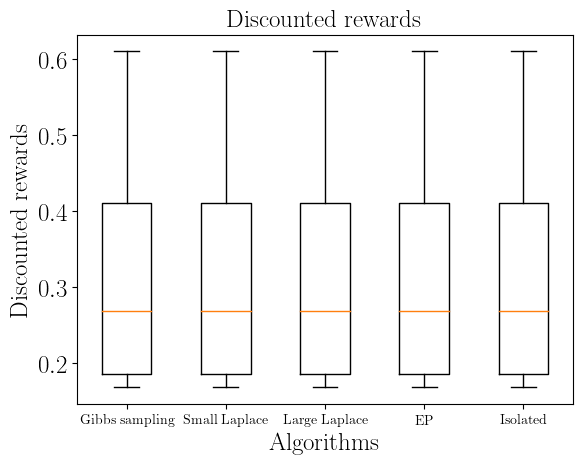

In [6]:
fig, ax = plt.subplots()
ax.boxplot(sim_accu, labels=['Gibbs sampling', 'Small Laplace', 'Large Laplace', 'EP', 'Isolated'])
ax.set_xlabel("Algorithms")
ax.set_ylabel("Discounted rewards")

plt.title("Discounted rewards")
plt.show()

In [13]:
with open(collab_file_name, 'r') as f:
    s_collab = json.load(f)
    
with open(ep_file_name, 'r') as f:
    s_ep = json.load(f)
    
with open(collab_lap_1_file_name, 'r') as f:
    s_collab_1 = json.load(f)

for i in range(len(s_collab['hist_cost'])):
    print(s_collab['hist_cost'][i])
    print(s_ep['hist_cost'][i])
    print('-'*20)

[[32, -5.036249016797891], [28, -39.00010388852365], [28, -5.037735964360181]]
[[32, -5.036249016797891], [28, -39.00010388852365], [28, -5.037735964360181]]
--------------------
[[40, -5.033448587928483], [32, -5.036249016797891], [30, -5.036985018669412]]
[[40, -5.033448587928483], [32, -5.036249016797891], [30, -5.036985018669412]]
--------------------
[[27, -5.0381171357173535], [34, -5.035527661363613], [30, -5.036985018669412]]
[[27, -5.0381171357173535], [34, -5.035527661363613], [30, -5.036985018669412]]
--------------------
[[30, -5.036985018669412], [59, -5.027634173858118], [31, -37.990266802930606]]
[[30, -5.036985018669412], [59, -5.027634173858118], [31, -37.990266802930606]]
--------------------


In [10]:
s_collab['mu_mean_hist'][0]

[0.9405047501013587, 0.866752014393006, 0.8176048326128257, 0.5801014241307375]

In [11]:
s_ep['mu_mean_hist'][0]

[3.7951660144000003, 3.72315653006, 3.69953562015, 3.5440585764800003]

In [14]:
s_collab_1['mu_mean_hist'][0]

[0.9176352719487512,
 0.8601628187363695,
 0.8091459937793147,
 0.5845369312334485]